<a href="https://colab.research.google.com/github/naathycc/Projeto-Panda-dez-2025/blob/main/ICD_Spotifytracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória de dados: Gêneros musicais no Spotify

Grupo:
- Alex José Duarte Sasaki
- Juliana Andrade Buono
- Nathália Cristina Cadeu

## Introdução
 Ouvir músicas no Spotify é um hábito muito popular no mundo todo e dados do seu consumo podem responder muitas perguntas pertinentes sobre o gosto dos usuários, como: Faixas mais curtas são mais populares? Faixas com vocais são mais populares do que as instrumentais? A popularidade é distribuída de forma diferente entre os gêneros? O perfil acústico tem influência na popularidade da faixa?

 Esse projeto usa o dataset Spotify Tracks Genre, que fornece diversas variáveis relevantes para responder às perguntas, desde dados gerais sobre a faixa até características da música, para que nosso grupo consiga fazer uma boa Análise Exploratória de Dados e encontre a correlação entre as características musicais da faixa e sua popularidade.



## 1. Carregando e Conhecendo os Dados

De início, precisamos acessar a fonte do dataset, checar suas varíaveis e configurá-lo para iniciarmos a análise.

### 1.1 Configurando o ambiente de trabalho

In [ ]:
# Importação das bibliotecas padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

### 1.2 Descrição e carregamento do Dataset

- Nome do dataset: Spotify Tracks Genre
- Fonte: https://www.kaggle.com/datasets/thedevastator/spotify-tracks-genre-dataset
- Descrição: Este conjunto de dados fornece informações abrangentes sobre as faixas do Spotify, englobando uma coleção diversificada de 125 gêneros.

O dataset está contido em um único arquivo "train.csv" e é uma coleção abrangente de faixas musicais da plataforma Spotify. Ele combina metadados de cada música (como nome da faixa, artista, álbum e popularidade) com um conjunto detalhado de características de áudio quantitativas fornecidas pela API do Spotify.

In [ ]:
# Carregamento do dataset.
path = kagglehub.dataset_download("thedevastator/spotify-tracks-genre-dataset")
file_path = path + '/train.csv'

df = pd.read_csv(file_path)

print("Dataframe carregado com sucesso!")

Using Colab cache for faster access to the 'spotify-tracks-genre-dataset' dataset.
Dataframe carregado com sucesso!


## 2. Preparação dos dados
Agora que o dataset foi carregado, vamos preparar os dados para uso, para isso vamos verificar todas suas variáveis e descrevê-las para melhor entendimento.

In [ ]:
print("Informações sobre o dataset")
df.info()

Informações sobre o dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float

### 2.1 Explicação sobre os atributos

Agora vamos entender do que se trata cada variável do nosso dataset. Podemos dividir essas variáveis em dois grandes grupos:

### Informações sobre a faixa
- track_id: Número identificador da faixa.
- artists: Artista responsável pela faixa.
- album_name: Álbum que contém a faixa.
- track_name: Nome da faixa.
- popularity: Popularidade da faixa (índice de 0 a 100).
- duration_ms: Duração da faixa em milisegundos.
- explicit: Indicador de conteúdo explícito (0 ou 1).
- track_genre: Gênero musical a qual a faixa pertence.

### Características musicais
- energy: Medida de intensidade da faixa.
- key: Tom musical da faixa, armazenado em valores inteiros.
- loudness: Volume percebido da faixa, medido em decibéis (dB).
- mode: Modalidade da escala musical da faixa.
- speechiness: Mede a presença de palavras faladas na faixa (oposto de palavras cantadas).
- acousticness: Índice de probabilidade de existência de som acústico na faixa.
- instrumentalsness: Mede a probabilidade de uma faixa não conter vocais ('instrumental').
- liveness: Índice de probabilidade de existência de público durante a gravação da faixa.
- valence: Índice que descreve a positividade musical de uma faixa.
- tempo: Mensuração do tempo musical, medido em batidas por minuto.
- time_signature: Número de batidas contidas em cada compasso da faixa.

### 2.2 Criando novas variáveis

Para obtermos conclusões mais ricas sobre os gêneros, precisamos ir além dos atributos brutos fornecidos. Para isso, criaremos novas variáveis estratégicas que relacionam os dados existentes.

* duracao_minutos: A duration_ms (duração em milissegundos) é difícil de interpretar. Partindo da hipótese de que a duração média varia por gênero, converteremos esse valor para minutos. Isso facilitará a visualização e a correlação com a popularidade.

* tonalidade_completa: O tom (key) e o modo (mode) são mais poderosos quando combinados. Consolidar essa informação em uma única variável categórica nos ajudará a avaliar se certos gêneros têm "assinaturas" tonais preferidas.

* tipo_de_faixa: Os parâmetros instrumentalness e speechiness nos permitem avaliar a natureza da faixa. Aqui trataremos faixas com alta instrumentalness como 'Instrumental', faixas com alta speechiness como 'Falada', e as demais como 'Vocal', nos permitindo comparar a composição dos gêneros.

* vibe_geral: Usaremos os parâmetros energy e valence (positividade). Partindo da hipótese de que músicas "alegres" (alta valência) e "energéticas" (alta energia) definem certos gêneros, faremos o produto deles para obter um escore de "energia positiva".

* perfil_acustico: Gêneros como "folk" e "classical" são muito diferentes de "electronic". Usando acousticness e energy, podemos criar uma variável que categorize a faixa para testar como esses perfis se distribuem.

In [ ]:
# Criação das novas variáveis:

df['duracao_minutos'] = round(df['duration_ms'] / 60000, 2)
df['vibe_geral'] = df['energy'] * df['valence']

# Para categorizar o Modo, mapearemos os valores de 0 a 11 como seus respectivos tons
key_map = {
    -1: 'N/A', #Não detectado
    0: 'C',
    1: 'C#',
    2: 'D',
    3: 'D#',
    4: 'E',
    5: 'F',
    6: 'F#',
    7: 'G',
    8: 'G#',
    9: 'A',
    10: 'A#',
    11: 'B'
}

mode_map = {
    0: 'Menor',
    1: 'Maior'
}

key_str = df['key'].map(key_map)
mode_str = df['mode'].map(mode_map)

# Combinação dos mapeamentos em uma única coluna
df['tonalidade_completa'] = key_str + '_' + mode_str


# Para implementar o Tipo de faixa, definiremos os limites de speechness e instrumentals
limite_instrumental = 0.5
limite_falas = 0.5

conditions = [
    df['instrumentalness'] > limite_instrumental,
    df['speechiness'] > limite_falas
]

choices = ['Instrumental', 'Falada']

# Criação da coluna com os parâmetros selecionados
df['tipo_de_faixa'] = np.select(conditions, choices, default='Vocal')


# Para implementar o perfil_acustico, também definiremos limites para o acousticness e energy
conds = [
    (df['acousticness'] > 0.5) & (df['energy'] < 0.5), # Alta Acústica, Baixa Energia
    (df['acousticness'] > 0.5) & (df['energy'] >= 0.5), # Alta Acústica, Alta Energia
    (df['acousticness'] <= 0.5) & (df['energy'] < 0.5), # Baixa Acústica, Baixa Energia
    (df['acousticness'] <= 0.5) & (df['energy'] >= 0.5) # Baixa Acústica, Alta Energia
]

choices = [
    'Acústica/Calma',
    'Acústica/Intensa',
    'Eletrônica/Calma',
    'Eletrônica/Intensa'
]

# Criação da coluna com os limites implementados
df['perfil_acustico'] = np.select(conds, choices, default='Indefinido')

print("Novas variáveis")
display(df[['duracao_minutos', 'vibe_geral', 'tonalidade_completa', 'tipo_de_faixa', 'perfil_acustico']])

Novas variáveis


,duracao_minutos,vibe_geral,tonalidade_completa,tipo_de_faixa,perfil_acustico
0,3.84,0.329615,C#_Menor,Vocal,Eletrônica/Calma
1,2.49,0.044322,C#_Maior,Vocal,Acústica/Calma
2,3.51,0.043080,C_Maior,Vocal,Eletrônica/Calma
3,3.37,0.008523,C_Maior,Vocal,Acústica/Calma
4,3.31,0.073981,D_Maior,Vocal,Eletrônica/Calma
...,...,...,...,...,...
113995,6.42,0.007966,F_Maior,Instrumental,Acústica/Calma
113996,6.42,0.004095,C_Menor,Instrumental,Acústica/Calma
113997,4.52,0.244447,C_Menor,Vocal,Acústica/Calma
113998,4.73,0.208978,G_Maior,Vocal,Eletrônica/Intensa


### 2.3 Pré-Processamento dos dados

Vamos começar a investigar a saúde dos nossos dados do Spotify. Isso envolve procurar por possíveis ruídos (dados mal formatados ou "sujos") e outliers (valores extremos que podem distorcer as análises).

No nosso contexto:

* Ruído poderia ser um track_name ou album_name com caracteres estranhos, ou uma faixa com track_id duplicada.

* Outliers seriam, por exemplo, uma música com 60 minutos em duracao_minutos (que pode ser um "mix" e não uma "faixa") ou valores de tempo (BPM) absurdamente baixos ou altos.

Podemos achar que, se a função .isnull() não retorna nada, os dados estão limpos. No entanto, dados faltantes podem se esconder na forma de textos. Por exemplo, em vez de NaN, poderíamos ter um artists listado como "Unknown", "N/A" ou simplesmente " " (espaços em branco).

Para investigar isso, faremos uma auditoria manual nas principais colunas categóricas (artists, album_name, track_genre) usando a função .value_counts() para procurar por esses valores "escondidos" e garantir a integridade dos gêneros e nomes.

In [ ]:
colunas_cat_auditoria = ['artists', 'album_name', 'track_name', 'track_genre','vibe_geral', 'tonalidade_completa','tipo_de_faixa', 'perfil_acustico']

print("Analisando valores nas colunas categóricas (identificando se há ruídos)")

# Este loop vai passar por cada coluna da lista e mostrar os valores que ela contém
for coluna in colunas_cat_auditoria:
    print(f"\nValores únicos na coluna '{coluna}':")
    print(df[coluna].value_counts())
    print("-" * 30)


# Podemos verificar também, se dentre os artistas não temos também linhas com conteúdo inadequado:
valores_ruins = ['N/A', 'Unknown', 'unknown', '?', '[unknown]', 'Various Artists', ""]
linhas_problematicas = df[df['artists'].isin(valores_ruins)]
print(f"Encontradas {len(linhas_problematicas)} linhas com valores ruins conhecidos:")
print(linhas_problematicas.head())

# Verificando se as faixas 'faladas' são faixas musicais ou outra categoria:
df_falada = df[df['tipo_de_faixa'] == 'Falada']
desc_faladas = df_falada.describe()
print(desc_faladas)

Analisando valores nas colunas categóricas (identificando se há ruídos)

Valores únicos na coluna 'artists':
artists
The Beatles                           279
George Jones                          271
Stevie Wonder                         236
Linkin Park                           224
Ella Fitzgerald                       222
                                     ... 
Hillsong Worship;TAYA;David Ware        1
for KING & COUNTRY;Andy Mineo           1
Bethel Music;Francesca Battistelli      1
Descansa                                1
Jesus Culture                           1
Name: count, Length: 31437, dtype: int64
------------------------------

Valores únicos na coluna 'album_name':
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
                              ... 
A Greater Song (Live)            1
This is Thetahealing             1
Phenomena (DA DA) 

Com essa análise, pudemos observar que o dataset está limpo, sem valores em ausentes e quaisquer padronização de resultados. Além disso verificamos também se as faixas categorizadas como 'Faladas' se encaixariam em outra categoria além de músicas, mas a categorização se explica pelo gênero musical, como Rap/Hip-Hop e demais variações.

Agora faremos uma verificação das variáveis numéricas, em busca de valores aberrantes que possam prejudicar a análise dos dados.

INVESTIGAÇÃO DE OUTLIER 



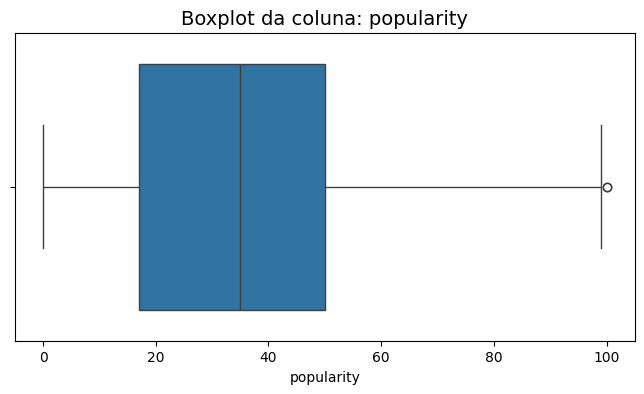

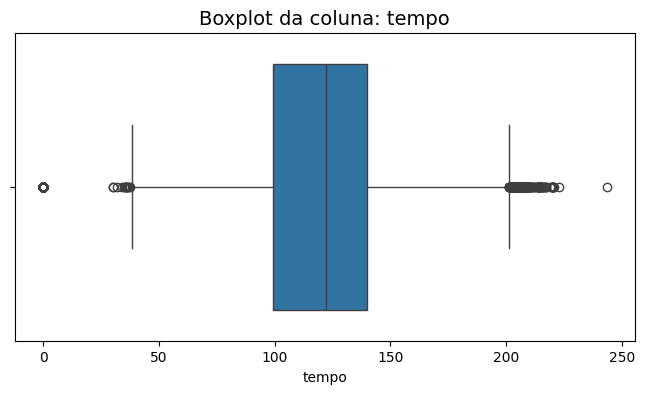

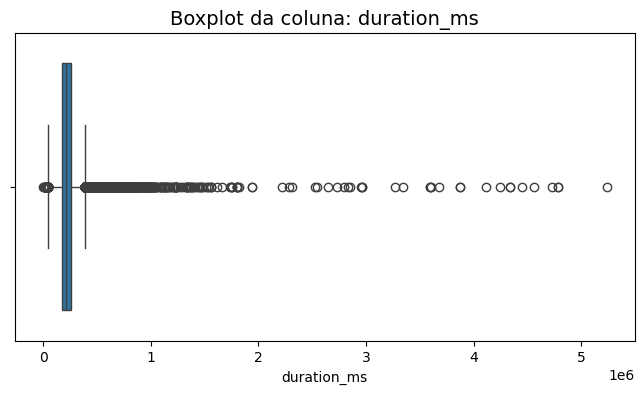

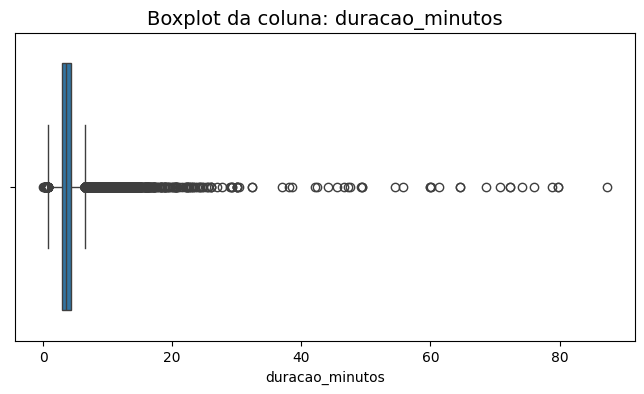

In [ ]:
colunas_para_boxplot = ['popularity', 'tempo', 'duration_ms', 'duracao_minutos']

print("INVESTIGAÇÃO DE OUTLIER \n")

# Criamos um loop para gerar um boxplot para cada coluna da lista
for coluna in colunas_para_boxplot:
    plt.figure(figsize=(8, 4)) # Cria uma nova figura para cada gráfico
    sns.boxplot(x=df[coluna])
    plt.title(f'Boxplot da coluna: {coluna}', fontsize=14)
    plt.show()

Com esses gráficos obtivemos dados aberrantes em todas as variáveis investigadas, entretanto, outliers nas colunas popularity e tempo podem ser dados válidos, no caso de popularity sendo músicas de grande sucesso e no caso do tempo, podem se tratar de remixes ou músicas ambiente com ritmo mais calmo.

Agora, se tratando de outliers na duração das faixas, sendo em ms ou em minutos, precisaremos investiga-las:

In [ ]:
# Vamos ver quantas faixas têm mais de 15 minutos
faixas_longas = df[df['duracao_minutos'] > 15]
print(f"Encontradas {len(faixas_longas)} faixas com mais de 15 minutos.")
print(faixas_longas[['track_name', 'artists', 'track_genre', 'duracao_minutos']])

limite_duracao = 15

Encontradas 151 faixas com mais de 15 minutos.
                                               track_name  \
4944                                1/1 - Remastered 2004   
6005                                            Fra dyden   
6057                                Floden, som kan skabe   
6106                                            Mod døden   
6160                          Trance/Floden, som kan lede   
...                                                   ...   
111803                                             Lights   
111833                                 Finding It So Hard   
111849  A Huge Ever Growing Pulsating Brain That Rules...   
113390                       Cantos Gregorianos Sanadores   
113688                 Ruido Rosa Puro - Una Hora Versión   

                      artists  track_genre  duracao_minutos  
4944                Brian Eno      ambient            17.36  
6005                      ORM  black-metal            24.64  
6057                      ORM  bla

In [ ]:
df_filtrado = df[df['duracao_minutos'] <= 15].copy()

Aqui encontramos faixas realmente longas de gêneros que possuem esse comportamento, mas também encontramos faixas longas que prejudicariam a nossa análise, como faixas com versão extendida e músicas de ambiente , como é o exemplo de 'El Ruido Blanco' sendo uma faixa com som ambiente sem nenhum propósito musical.

Por isso, iremos usar o filtro de até 15 minutos, para que a análise de duração de faixa versus a popularidade não seja distorcida.

### 2.4 Discretização de dados

Já iniciamos esse processo de categorizar algumas variáveis numéricas, mas ainda há algumas variáveis que podem se beneficiar da discretização:

* tempo: agruparemos em 5 categorias, sendo elas: Muito Lento, Lento, Moderado, Rápido e Muito rápido.

* duracao_minutos: também agruparemos em 5 categorias: Curta, Padrão, Longa e Épica.

* popularity: agruparemos em 4 categorias: Baixa, Média, Popular e Hit.

* loudness: agruparemos em 4 categorias: Muito baixo, Baixo, Médio e Alto.

In [ ]:
# Definimos as faixas de corte para as novas duas categorizações e associamos cada faixa com seu rótulo:

tempo_bins = [
    0,     # Início
    70,    # Muito Lento (ex: Ambient)
    90,    # Lento (ex: Hip-Hop)
    120,   # Moderado (ex: Pop/Dance "padrão")
    140,   # Rápido (ex: Rock/Punk)
    250    # Teto máximo (para pegar tudo)
]

tempo_labels = ['Muito Lento', 'Lento', 'Moderado', 'Rápido', 'Muito Rápido']

df['faixa_de_tempo'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)



duracao_bins = [
    0,     # Início
    2.5,   # Curtas (ex: intros, interlúdios, punk)
    5,     # Padrão (a maioria das músicas pop/rock)
    8,     # Longas (ex: faixas de rock progressivo)
    15     # Teto máximo (o que você definiu como filtro)
]

duracao_labels = ['Curta (<2.5m)', 'Padrão (2.5-5m)', 'Longa (5-8m)', 'Épica (8-15m)']

df_filtrado['faixa_de_duracao'] = pd.cut(df_filtrado['duracao_minutos'], bins=duracao_bins, labels=duracao_labels, right=False)


pop_bins = [
    -1,    # Início
    30,    # Faixa 1: 'Baixa' (Onde a maioria das músicas está)
    60,    # Faixa 2: 'Média'
    80,    # Faixa 3: 'Popular'
    101    # Faixa 4: 'Hit' (Pegando de 80 a 100)
]

pop_labels = ['Baixa', 'Média', 'Popular', 'Hit']

df_filtrado['faixa_de_popularidade'] = pd.cut(df_filtrado['popularity'], bins=pop_bins, labels=pop_labels, right=False)


loudness_bins = [
    -60,   # Início (para pegar até os mais silenciosos)
    -15,   # Faixa 1: 'Muito Baixo' (ex: ambient, classical)
    -10,   # Faixa 2: 'Baixo'
    -6,    # Faixa 3: 'Médio/Padrão' (onde a maioria deve estar)
    0      # Faixa 4: 'Alto' (músicas "loudness war")
]

loudness_labels = ['Muito Baixo', 'Baixo', 'Médio/Padrão', 'Alto']

df_filtrado['faixa_de_loudness'] = pd.cut(df_filtrado['loudness'], bins=loudness_bins, labels=loudness_labels, right=False)



display(df_filtrado[['faixa_de_tempo', 'faixa_de_duracao', 'faixa_de_popularidade', 'faixa_de_loudness']].sample(10))

,faixa_de_tempo,faixa_de_duracao,faixa_de_popularidade,faixa_de_loudness
35952,Muito Rápido,Padrão (2.5-5m),Média,Alto
47973,Muito Rápido,Longa (5-8m),Popular,Baixo
79767,Moderado,Curta (<2.5m),Média,Muito Baixo
64320,Lento,Padrão (2.5-5m),Baixa,Médio/Padrão
106182,Lento,Padrão (2.5-5m),Popular,Muito Baixo
70427,Rápido,Padrão (2.5-5m),Média,Alto
58377,Moderado,Curta (<2.5m),Baixa,Médio/Padrão
102275,Lento,Padrão (2.5-5m),Baixa,Baixo
65264,Moderado,Padrão (2.5-5m),Popular,Alto
527,Moderado,Padrão (2.5-5m),Média,Baixo


### 2.5 Padronização de Variáveis Booleanas

No nosso dataset, há apenas uma variável booleana: implicit, portanto, vamos categoriza-la em 1 para "Yes" e 0 para para "No". Dessa forma, poderemos utilizar essa coluna para métricas numéricas.

In [ ]:
# Vamos converter os valores da coluna Explicit, sendo False receberá o valor 0 e True recebe o valor 1.
print(df_filtrado['explicit'].value_counts())


print("Transformando a coluna 'explicit' para 1 e 0...")
df_filtrado.loc[:, 'explicit'] = df_filtrado['explicit'].astype(int)

print("\nValores únicos APÓS a transformação:")
print(df_filtrado['explicit'].value_counts())

print("\nPercentual de faixas explícitas (1):")
print(f"{df_filtrado['explicit'].mean():.2%}")

explicit
False    104107
True       9742
Name: count, dtype: int64
Transformando a coluna 'explicit' para 1 e 0...

Valores únicos APÓS a transformação:
explicit
0    104107
1      9742
Name: count, dtype: int64

Percentual de faixas explícitas (1):
8.56%


/tmp/ipython-input-3167555557.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_filtrado.loc[:, 'explicit'] = df_filtrado['explicit'].astype(int)


## 3. Análise exploratória de dados

Agora com os dados tratados, padronizados, sem ruídos e aprimorados com novas variávels, partiremos para a análise dos dados.

Inicialmente apresentaremos os dados de cada variável separadamente, em seguida correlacionaremos as variáveis para testar algumas hipóteses.

### 3.1 Análise Univariada

Vamos olhar para as variáveis categóricas e numéricas que podem apresentar valores importantes para nossa análise:


 Distribuição de Frequências das Variáveis


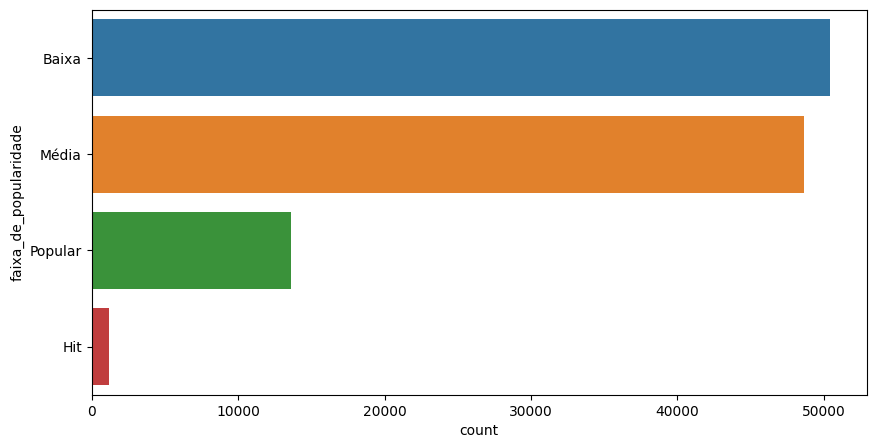

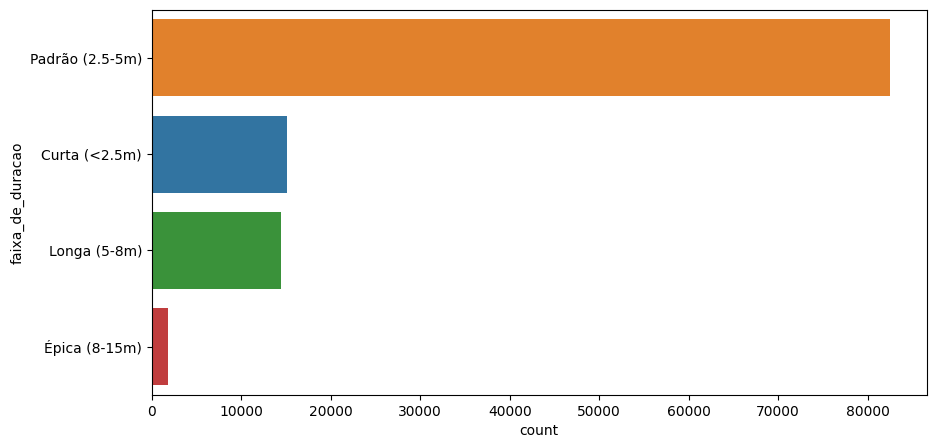

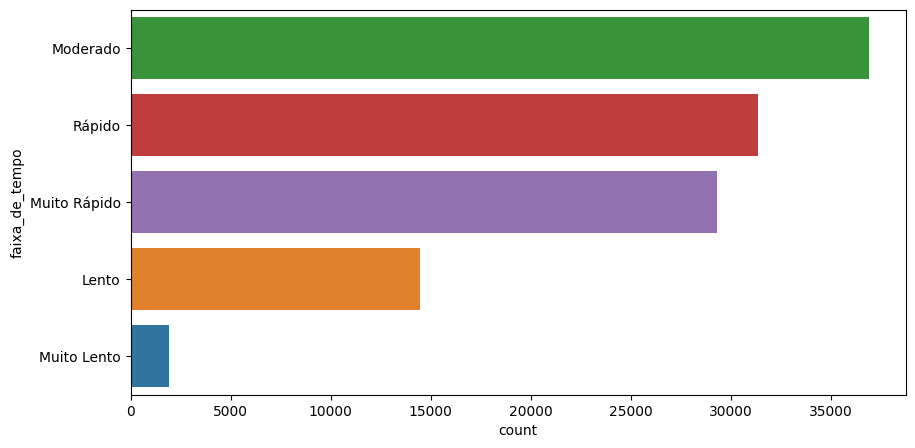

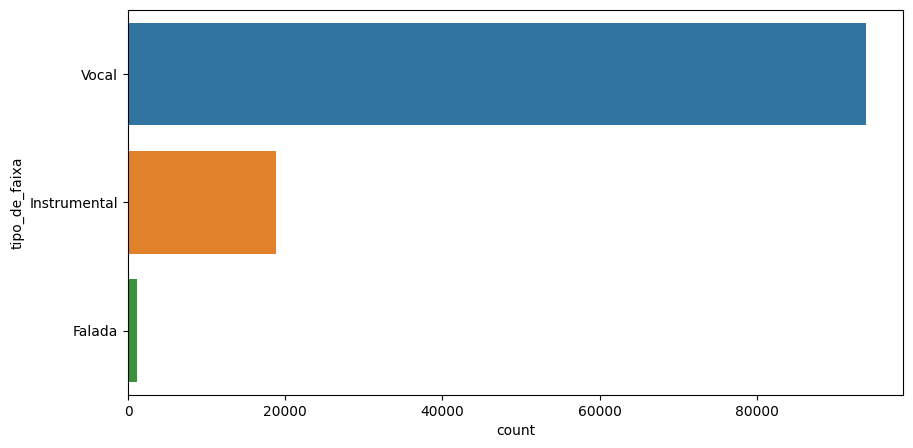

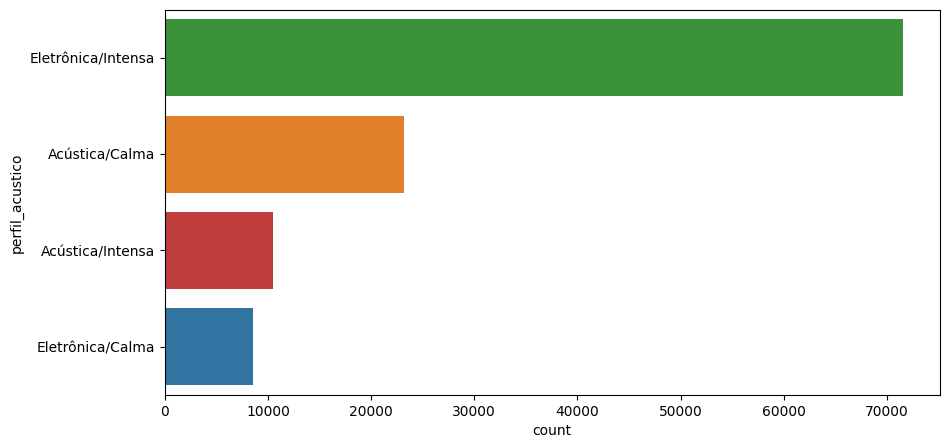

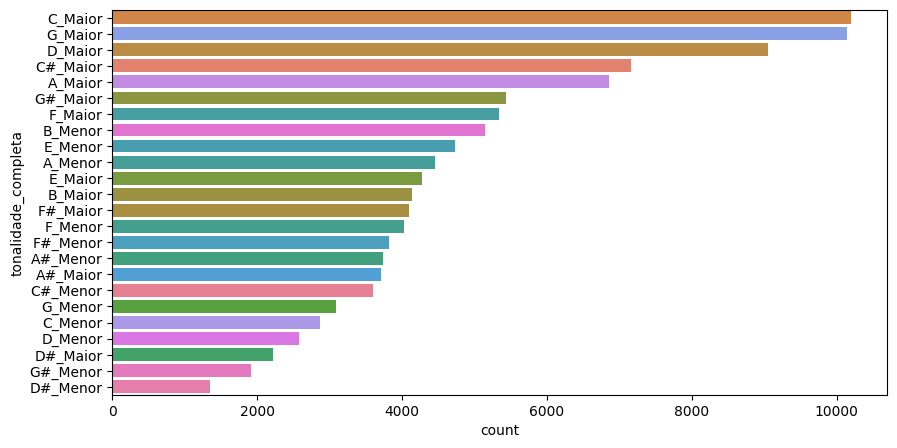

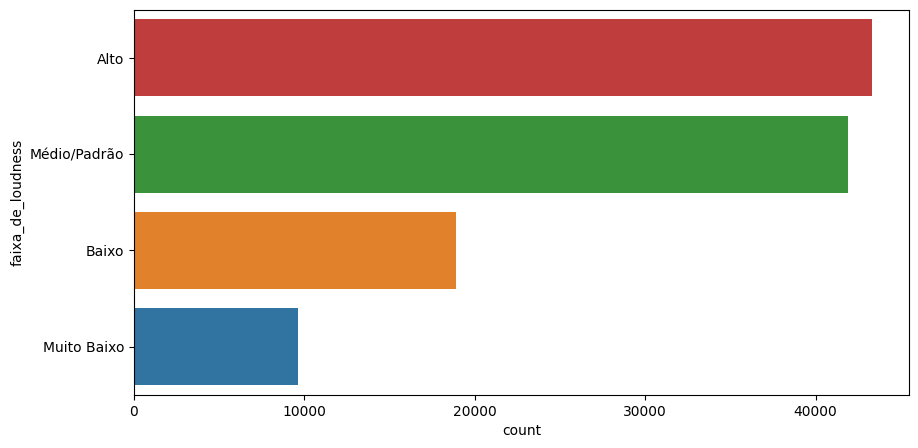

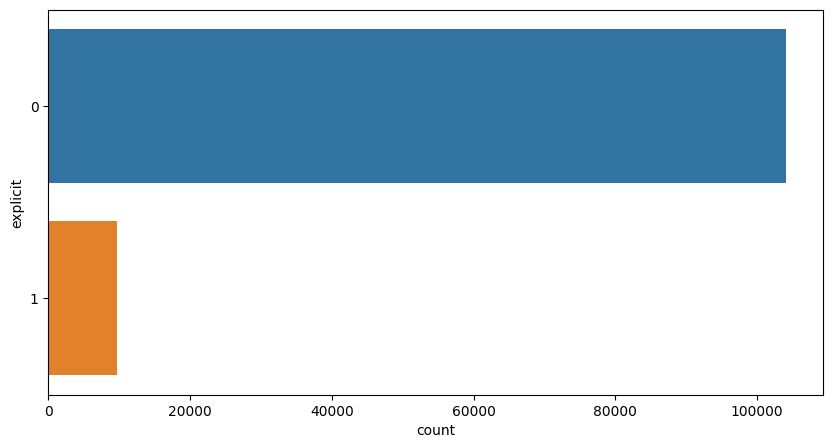

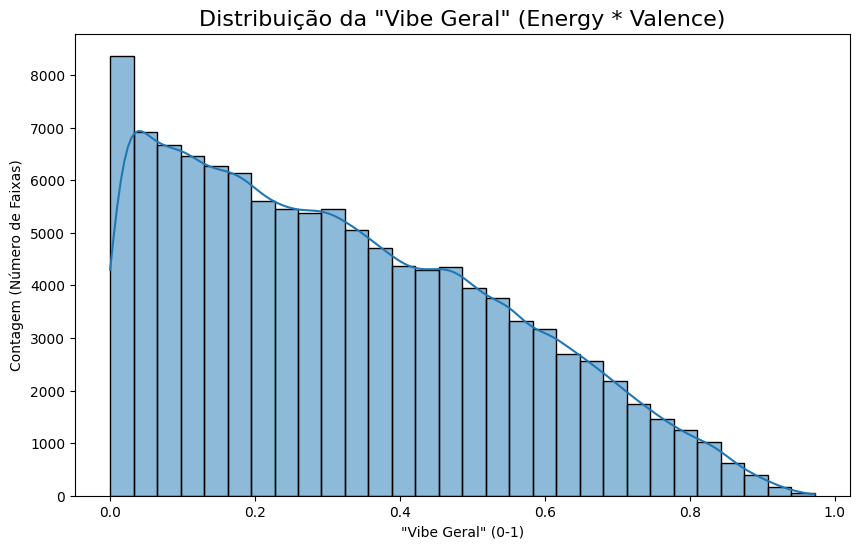

In [ ]:
# Distribuição de frequência das nossas principais variáveis categóricas
print("\n Distribuição de Frequências das Variáveis")

# Lista de colunas para analisar
colunas_categoricas = ['faixa_de_popularidade', 'faixa_de_duracao', 'faixa_de_tempo', 'tipo_de_faixa', 'perfil_acustico', 'tonalidade_completa', 'faixa_de_loudness','explicit']

for coluna in colunas_categoricas:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        y=coluna,
        data=df_filtrado,
        hue=coluna,
        legend=False,
        order=df_filtrado[coluna].value_counts().index
    )

plt.figure(figsize=(10, 6))
# Use o histplot (histograma)
sns.histplot(
    data=df_filtrado,
    x='vibe_geral',
    kde=True,  # Linha de densidade
    bins=30    # 30 faixas deve ser um bom começo
)
plt.title('Distribuição da "Vibe Geral" (Energy * Valence)', fontsize=16)
plt.xlabel('"Vibe Geral" (0-1)')
plt.ylabel('Contagem (Número de Faixas)')
plt.show()

Para a variável track_genre, usaremos um filtro dos gêneros musicais que mais ocorrem, devido a grande variedade de gêneros presentes no dataset.

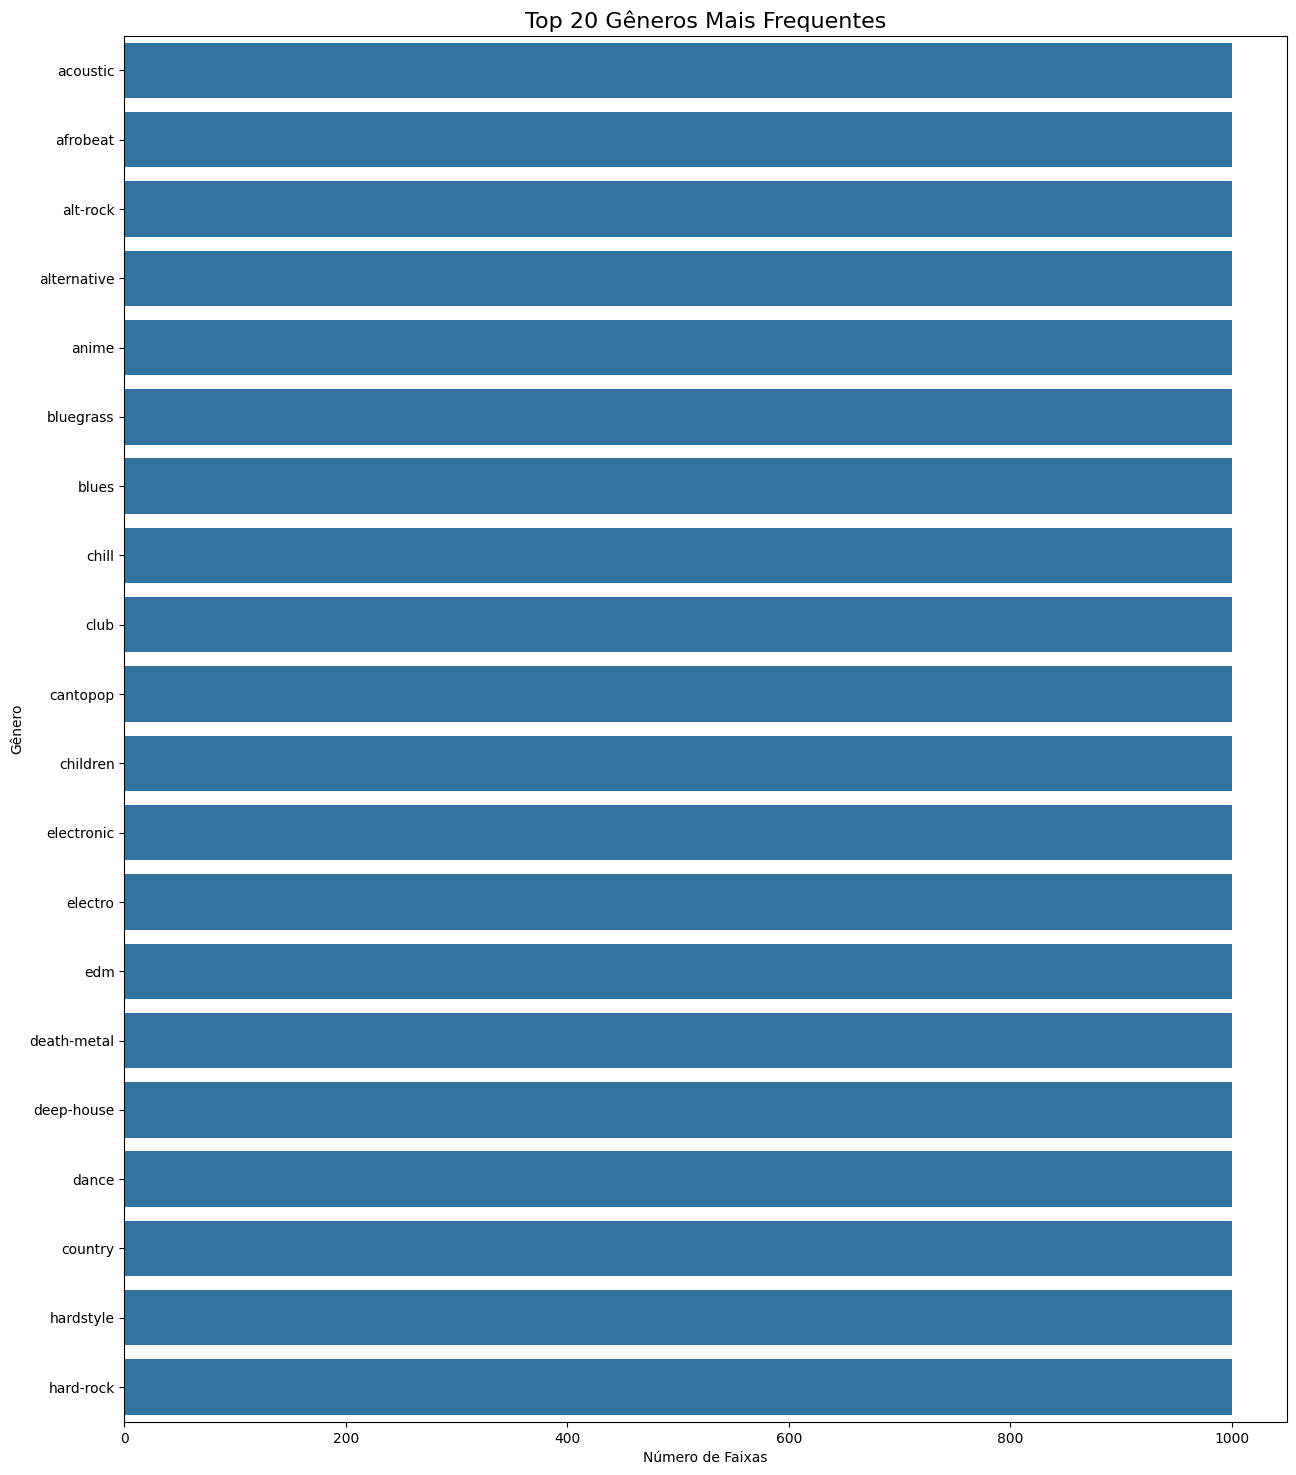

In [ ]:
# Vamos pegar os Top 20 gêneros
top_20_generos = df_filtrado['track_genre'].value_counts().head(20)

plt.figure(figsize=(15, 18))
sns.barplot(
    y=top_20_generos.index,
    x=top_20_generos.values,
    orient='h'
)
plt.title('Top 20 Gêneros Mais Frequentes', fontsize=16)
plt.xlabel('Número de Faixas')
plt.ylabel('Gênero')
plt.show()

Também precisamos adicionar as colunas originais para efeitos de análise:

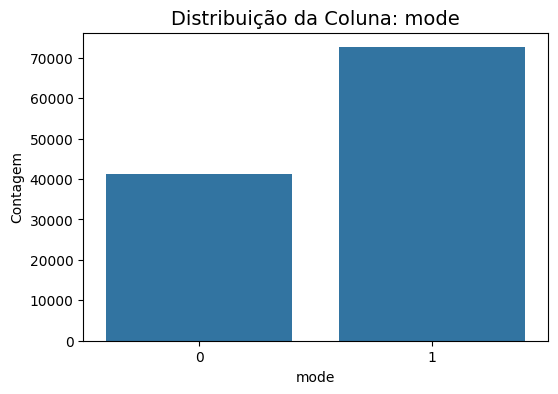

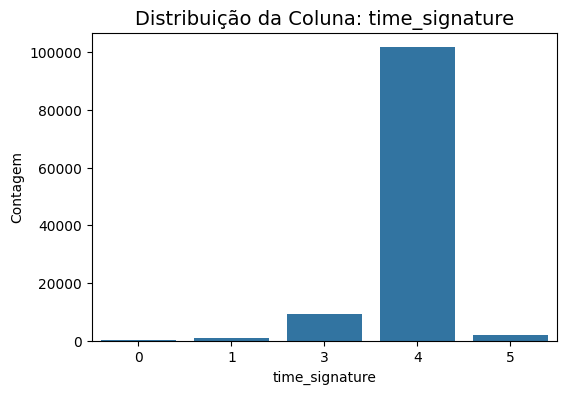

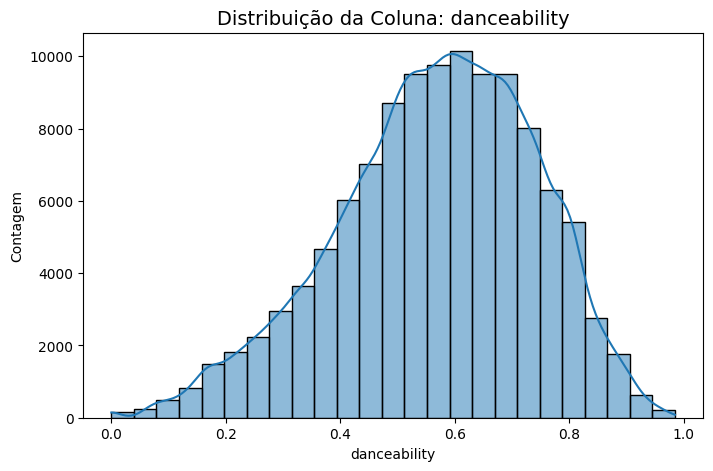

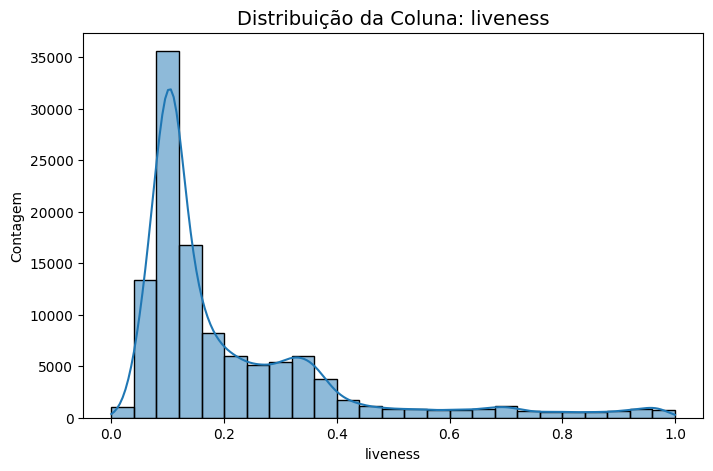

In [ ]:
colunas_categoricas_originais = ['mode', 'time_signature']

for coluna in colunas_categoricas_originais:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_filtrado, x=coluna)
    plt.title(f'Distribuição da Coluna: {coluna}', fontsize=14)
    plt.xlabel(coluna)
    plt.ylabel('Contagem')
    plt.show()

colunas_numericas_originais = ['danceability', 'liveness', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness']

for coluna in ['danceability', 'liveness']:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_filtrado, x=coluna, kde=True, bins=25)
    plt.title(f'Distribuição da Coluna: {coluna}', fontsize=14)
    plt.xlabel(coluna)
    plt.ylabel('Contagem')
    plt.show()

Com a análise dos gráficos de frequência, podemos obter os seguintes dados:

* Popularidade: A maior parte das faixas tem popularidade baixa;
* Intensidade: A grande maioria das faixas tem volume percebido e perfil acústico intenso. E em geral são músicas animadas para dançar;
* Gênero músical: Os 50 gêneros mais populosos possuem quantidades de faixas similares, ou seja, o dataset tem gêneros bem distribuídos.
* Gravação: a maioria das músicas não é gravada "ao vivo", ou seja, há pouca presença de público nas gravações.

### 3.2 Análise Bivariada
Nesse tópico, vamos relacionar mais de uma variável simultaneamente para responder as perguntas iniciais.

**Pergunta 1:** A duração de uma faixa afeta a sua popularidade?




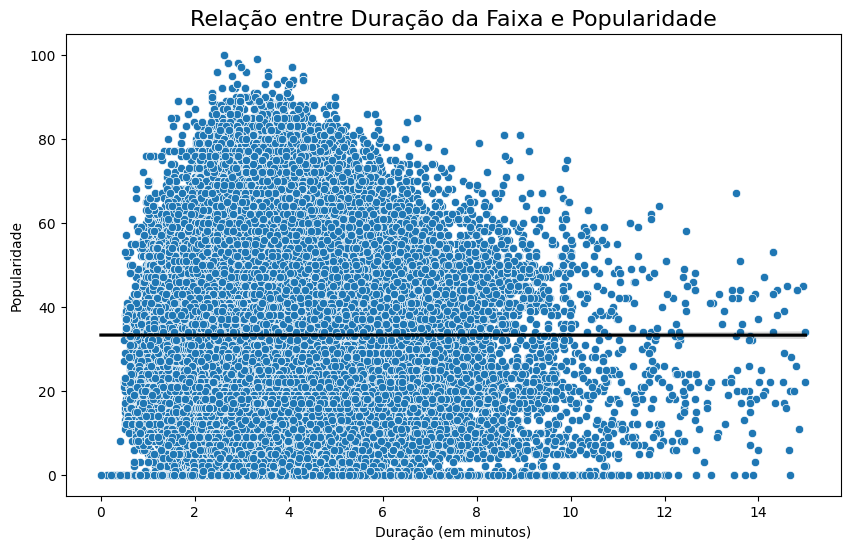

/tmp/ipython-input-3529497720.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


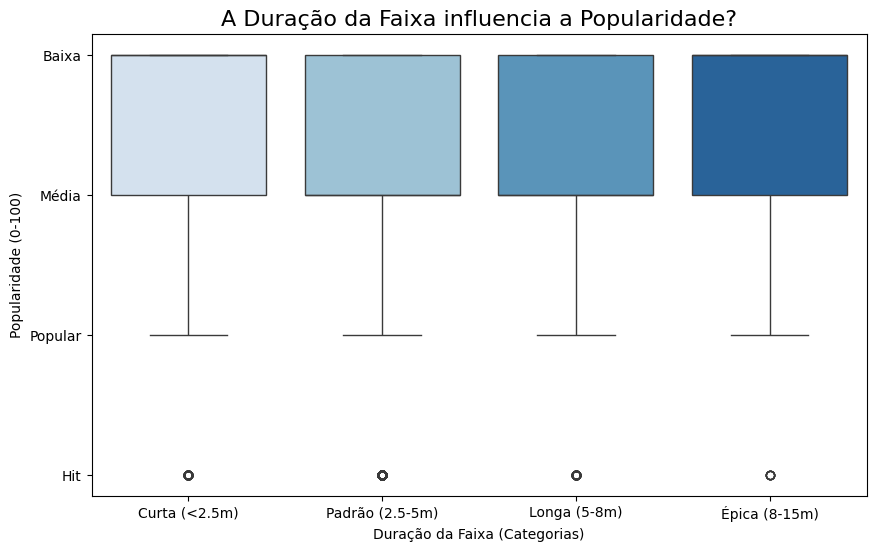

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot( # escolhi esse gráfico, pois apresenta uma melhor visualização da relação entre a popularidade e duração da faixa.
    data=df_filtrado,
    x='duracao_minutos',
    y='popularity',
)

sns.regplot(
    data=df_filtrado,
    x='duracao_minutos',
    y='popularity',
    scatter=False,
    color='black'
)

plt.title('Relação entre Duração da Faixa e Popularidade', fontsize=16)
plt.xlabel('Duração (em minutos)')
plt.ylabel('Popularidade')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtrado,
    x='faixa_de_duracao',
    y='faixa_de_popularidade',
    palette='Blues'
)
plt.title('A Duração da Faixa influencia a Popularidade?', fontsize=16)
plt.xlabel('Duração da Faixa (Categorias)')
plt.ylabel('Popularidade (0-100)')
plt.show()




O gráfico mostra que existe  uma correlação negativa entre duração e popularidade, no sentido que faixas mais curtas possuem uma popularidade maior que as faixas mais longas, principalmente em relação a duração de 2 a 5 minutos, que é a duração mais comum das músicas atuais. Além disso, nas faixas com duração igual ou superior a 6 minutos, o gráfico tem uma leva queda e acima dos 10 minutos a popularidade fica muito mais dispersa, assim, músicas mais longas tendem a ser menos populares que as faixas curtas.

> Add blockquote



**Pergunta 2:** A popularidade de uma música está correlacionada com alguma característica de áudio?

Para respondermos essa pergunta nessa seção, dividiremos em sub perguntas com determinadas características:
* Faixas com vocais são mais populares do que as instrumentais?


/tmp/ipython-input-2645924951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


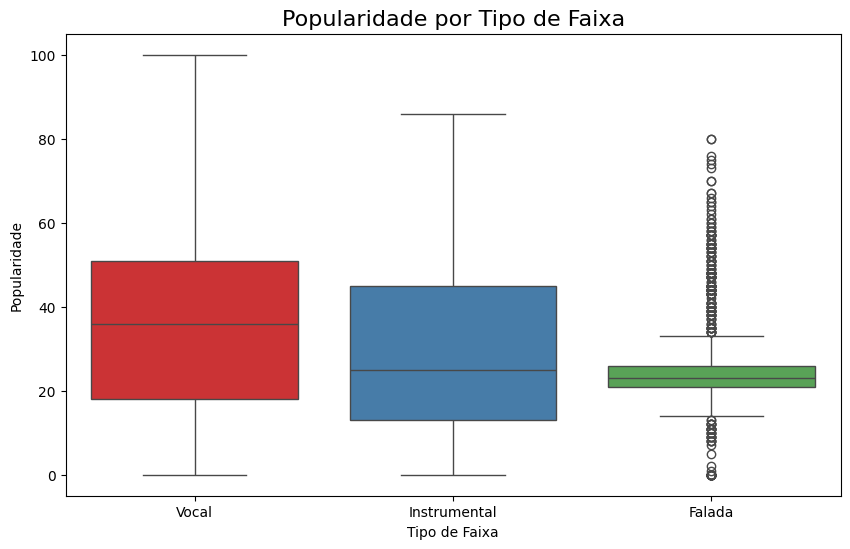

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtrado,
    x='tipo_de_faixa',
    y='popularity',
    palette='Set1'
)

plt.title('Popularidade por Tipo de Faixa', fontsize=16)
plt.xlabel('Tipo de Faixa')
plt.ylabel('Popularidade')
plt.show()



Esse boxplot mostra que faixas com vocais são mais populares com o público, visto que apresentam uma mediana maior que as outras duas faixas, as instrumentais apresentam as segundas medianas mais populares, com algumas músicas apresentando bastante popularidade mas menos aceitas pelo público e as músicas faladas são as menos populares, mas possuem faixas que são muito populares. Assim, músicas com vocais são mais populares que as instrumentais, e essas são mais populares que as faladas.

* O perfil acústico tem influência na popularidade da faixa?

/tmp/ipython-input-2506285762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


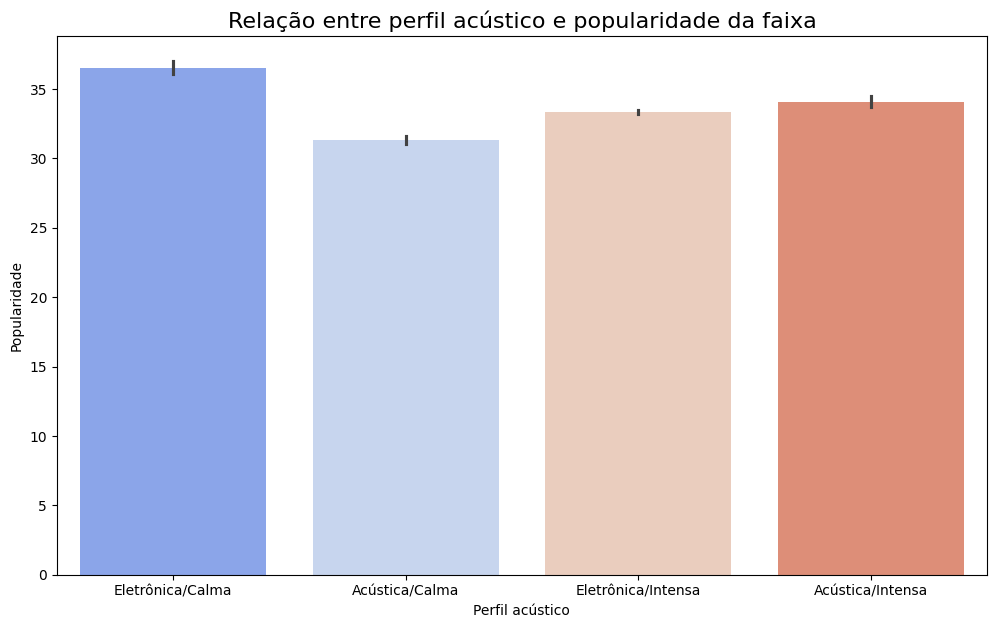

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x='perfil_acustico',
    y='popularity',
    data=df_filtrado,
    palette='coolwarm',
    legend=False,
)

plt.title('Relação entre perfil acústico e popularidade da faixa', fontsize=16)
plt.xlabel('Perfil acústico')
plt.ylabel('Popularidade')
plt.show()


A média de popularidade das músicas desse dataset fica entre 30 a 35 pontos de popularidade. A maioria das faixas tem popularidade baixa ou moderada, mantendo a média reduzida, sendo exibida como máxima nesse gráfico. Analisando o perfil acústico, conclui-se que as músicas classificadas como Eletrônica/Calma apresentam as maiores médias de popularidade, enquanto as faixas Acústica/Calma são as menos populares entre as categorias. Portanto, o perfil acústico tem influência na popularidade da faixa.

* O Ritmo da música está relacionado com a popularidade?

/tmp/ipython-input-404526384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


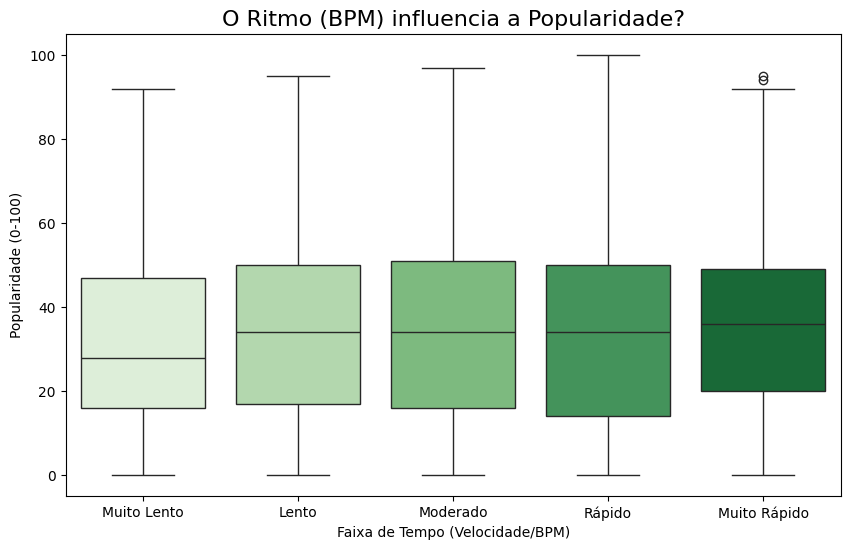

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtrado,
    x='faixa_de_tempo',
    y='popularity',
    palette='Greens'
)
plt.title('O Ritmo (BPM) influencia a Popularidade?', fontsize=16)
plt.xlabel('Faixa de Tempo (Velocidade/BPM)')
plt.ylabel('Popularidade (0-100)')
plt.show()

Nesse gráfico podemos observar que a mediana de todas as faixas de tempo estão muito próximas, com outliers mais populares em músicas com batidas mais rápidas, pode-se dizer que esta característica não determina a popularidade.

* A tonalidade da faixa afeta a popularidade?

/tmp/ipython-input-4203213048.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


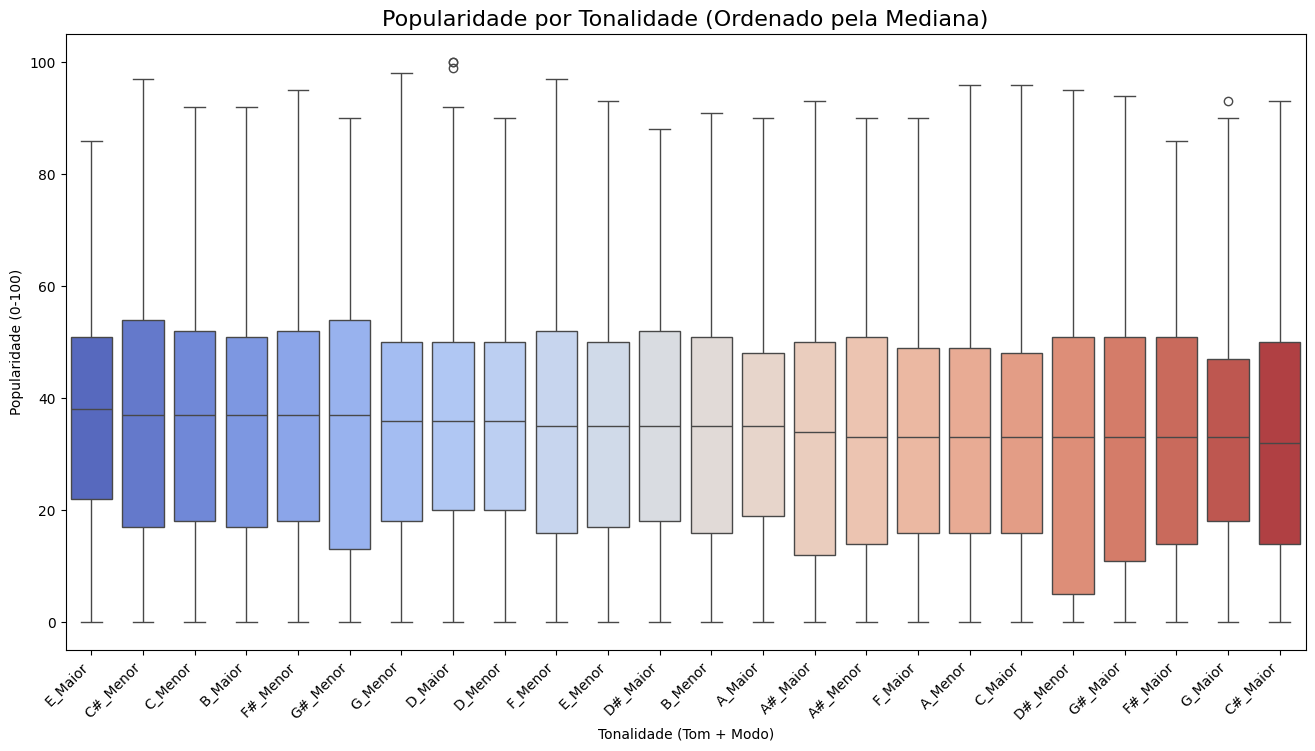

In [ ]:
plt.figure(figsize=(16, 8)) a)
ordem_tonalidade = df_filtrado.groupby('tonalidade_completa')['popularity'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_filtrado,
    x='tonalidade_completa',
    y='popularity',
    order=ordem_tonalidade,
    palette='coolwarm'
)
plt.title('Popularidade por Tonalidade (Ordenado pela Mediana)', fontsize=16)
plt.xlabel('Tonalidade (Tom + Modo)')
plt.ylabel('Popularidade (0-100)')
plt.xticks(rotation=45, ha='right')
plt.show()

Novamente observamos medianas muito próximas, também com outliers, dessa vez em Dó Maior e Sol Maior, que por sua vez são conhecidos pela leveza e agradabilidade sonora.

* O Volume percebido afeta a popularidade?

/tmp/ipython-input-3318555742.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


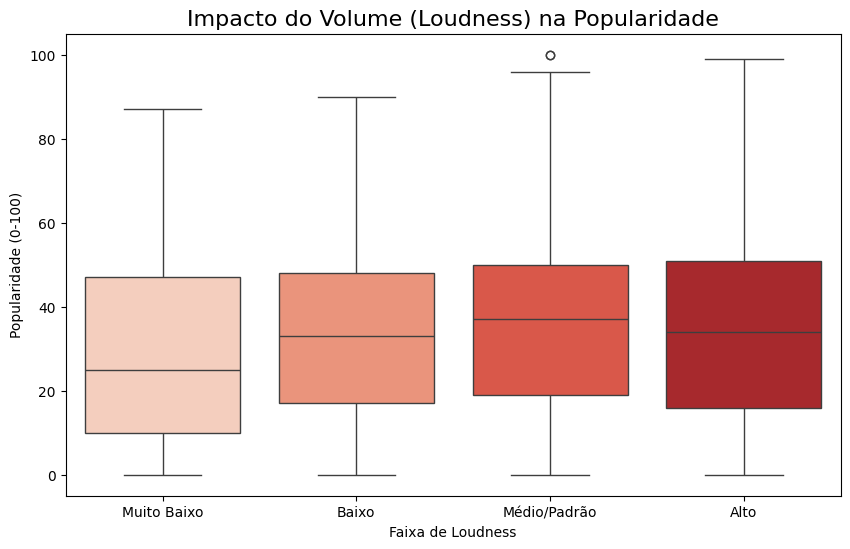

In [ ]:
plt.figure(figsize=(10, 6))

ordem_loudness = ['Muito Baixo', 'Baixo', 'Médio/Padrão', 'Alto']

sns.boxplot(
    data=df_filtrado,
    x='faixa_de_loudness',
    y='popularity',
    order=ordem_loudness,
    palette='Reds'
)
plt.title('Impacto do Volume (Loudness) na Popularidade', fontsize=16)
plt.xlabel('Faixa de Loudness')
plt.ylabel('Popularidade (0-100)')
plt.show()

Apesar de mantermos a mediana das faixas próximas, as músicas com volume percebido Muito Baixo apresentam mais faixas com popularidade abaixo de 20.

Com essas subperguntas podemos observar que individualmente não há influência na popularidade, ná próxima seção, correlacionaremos todas para verificar se esse comportamento se mantém.

**Pergunta 3:** A popularidade é distribuída de forma diferente entre os gêneros?

/tmp/ipython-input-882277890.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


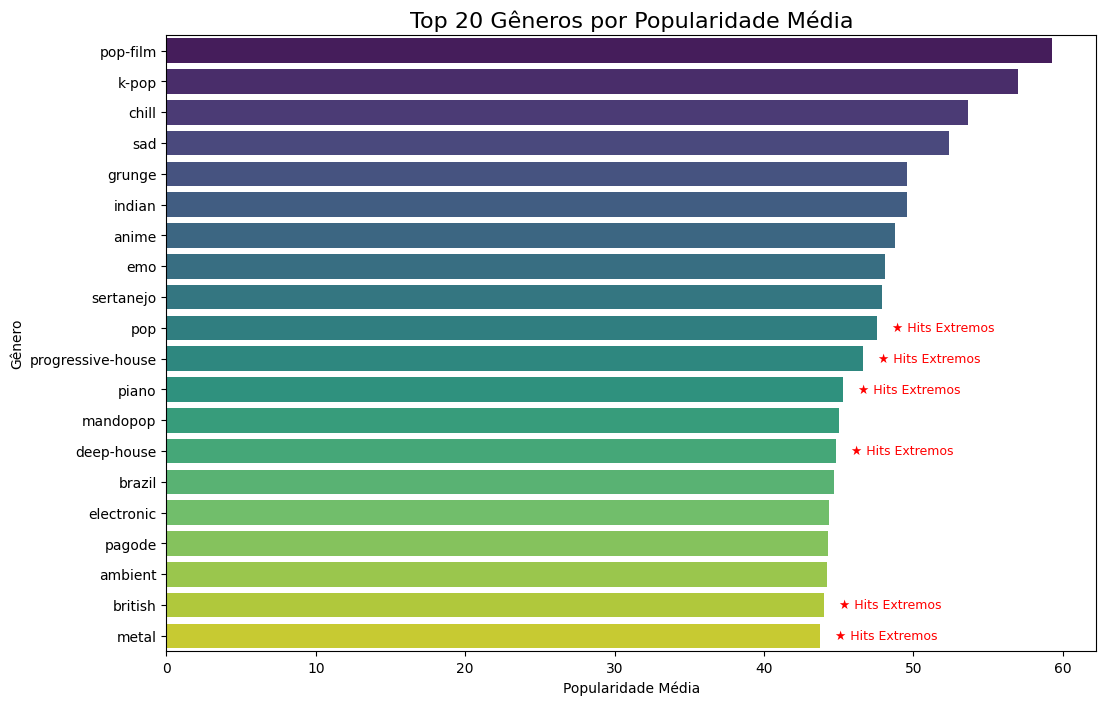

In [ ]:
analise_genero = df_filtrado.groupby('track_genre')['popularity'].agg(
    Mediana='median',
    Media='mean',
    Maximo='max',
    Total_Zeros=lambda x: (x==0).sum()
).reset_index()

# Selecionamos os top 20
top_generos_media = analise_genero.sort_values(by='Media', ascending=False).head(20)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_generos_media,
    x='Media',
    y='track_genre',
    palette='viridis'
)

plt.title('Top 20 Gêneros por Popularidade Média', fontsize=16)
plt.xlabel('Popularidade Média')
plt.ylabel('Gênero')

# Marcação dos Outliers Populares mesmo que seu gênero não seja o mais popular
for i, (index, row) in enumerate(top_generos_media.iterrows()):
    if (row['Maximo'] - row['Media']) > 40:
        plt.text(
            x = row['Media'] + 1,
            y = i,
            s = '★ Hits Extremos',
            color='red',
            fontsize=9,
            va='center'
        )

plt.show()

A distribuição de popularidade varia drasticamente entre os gêneros, revelando perfis de consumo distintos. Gêneros como 'pop-film' e 'k-pop' lideram o ranking devido à alta consistência, apresentando poucas faixas com baixa audiência, um padrão compartilhado por gêneros funcionais como 'chill'. Em contraste, estilos de massa como 'pop' e 'metal' demonstram um comportamento volátil: embora sejam responsáveis pelos maiores hits globais (máximos de 100), suas médias são penalizadas por uma "longa cauda" de faixas impopulares, caracterizando-os como mercados de "alto risco e alta recompensa".



### 3.3 Análise Multivariada

Para entendermos a popularidade de uma faixa, vamos correlaciona-la com as variáveis numéricas, gerando um mapa de calor para entendermos os fatores que elevam ou diminuem a popularidade.

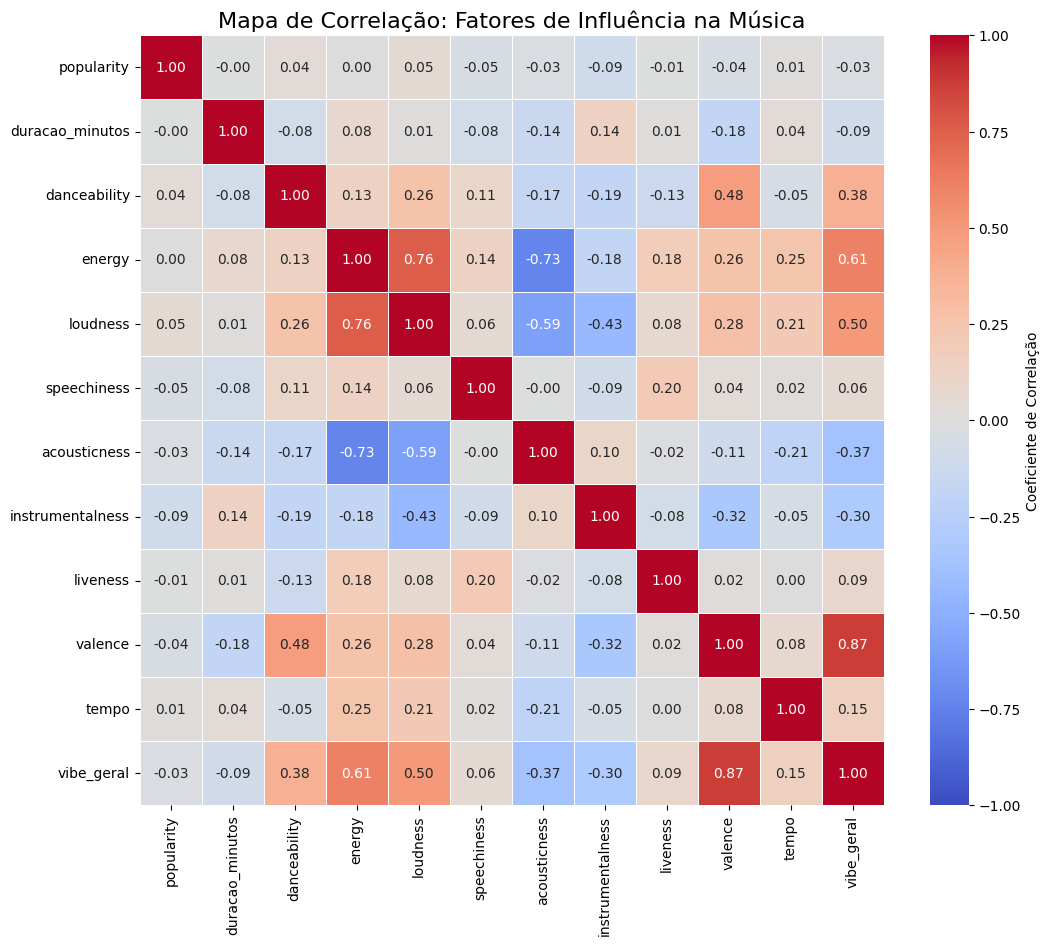

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Incluímos as variáveis originais e as novas variáveis que criamos (duracao_minutos, vibe_geral)
colunas_interesse = [
    'popularity',
    'duracao_minutos',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'vibe_geral'
]

# Verificação de segurança: seleciona apenas colunas que existem no seu df_filtrado
colunas_plot = [col for col in colunas_interesse if col in df_filtrado.columns]

# 2. Calcular a matriz de correlação
matriz_correlacao = df_filtrado[colunas_plot].corr()

# 3. Gerar o Mapa de Calor
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_correlacao,
    annot=True,        # Escreve os valores nos quadrados
    fmt=".2f",         # Formatação com 2 casas decimais
    cmap='coolwarm',   # Cores: Azul (Negativo) <-> Vermelho (Positivo)
    center=0,          # O branco fica no zero
    vmin=-1, vmax=1,   # Garante que a escala vá de -1 a 1
    linewidths=0.5,    # Linhas brancas entre os quadrados para separar
    cbar_kws={'label': 'Coeficiente de Correlação'}
)

plt.title('Mapa de Correlação: Fatores de Influência na Música', fontsize=16)
plt.show()

A análise de correlação linear (Heatmap) demonstrou que não existe uma 'fórmula mágica' universal de características de áudio que garanta a popularidade. As correlações globais próximas a zero indicam que o sucesso de uma faixa é dependente do contexto (gênero musical) ou de fatores externos (artista, marketing), e não apenas de ser 'mais rápida' ou 'mais alta'. Além disso, a diversidade de gêneros no dataset faz com que características opostas se anulem na análise global.

Agora, podemos correlacionar as características de gêneros musicais distintos. No mapa de calor a seguir teremos a coloração mais escura para alta correlação e coloração mais clara para baixa correlação.

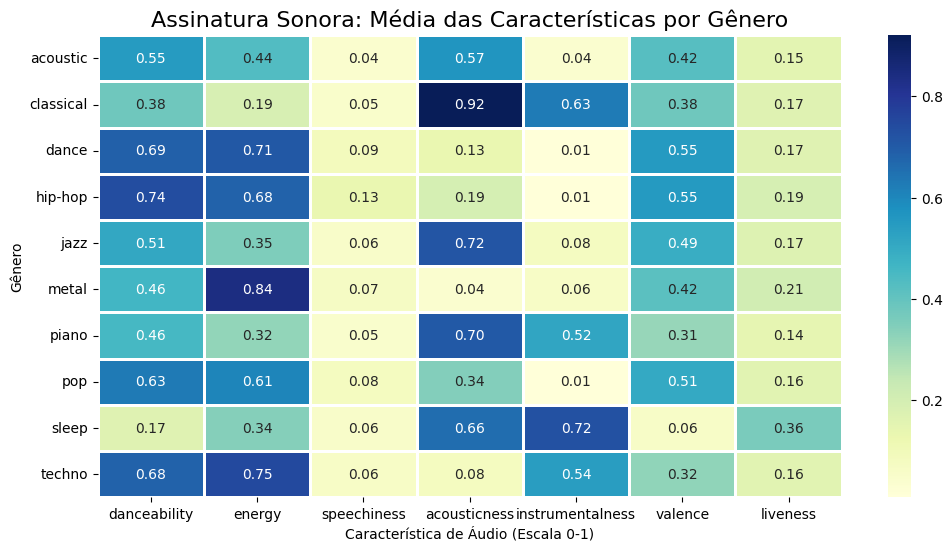

In [ ]:
colunas_audio = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'liveness']

#Selecionamos alguns gêneros distintos para comparação
generos_foco = [
    'metal', 'classical', 'pop', 'acoustic', 'dance',
    'piano', 'hip-hop', 'jazz', 'techno', 'sleep'
]

df_generos = df_filtrado[df_filtrado['track_genre'].isin(generos_foco)]
perfil_sonoro = df_generos.groupby('track_genre')[colunas_audio].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_sonoro,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    linewidths=1
)

plt.title('Assinatura Sonora: Média das Características por Gênero', fontsize=16)
plt.ylabel('Gênero')
plt.xlabel('Característica de Áudio (Escala 0-1)')
plt.show()

A análise multivariada confirma que, embora não exista uma 'fórmula mágica' universal para a popularidade, cada gênero musical é regido por uma 'assinatura sonora' técnica e inconfundível. O mapa de calor revela perfis opostos e complementares: gêneros de alta intensidade, como Metal e Techno, são definidos por níveis extremos de Energia e baixa Acusticidade, enquanto gêneros funcionais, como Classical e Sleep, apresentam o comportamento inverso, sendo dominados pela Instrumentalidade e calma. Isso valida a qualidade dos dados, demonstrando que a classificação de gêneros do Spotify segue parâmetros quantitativos rígidos e consistentes.

Além disso, essa análise explica o fenômeno da baixa correlação global encontrada anteriormente. Observamos que os atributos de áudio funcionam de maneira contextual: a alta Speechiness (fala), por exemplo, é um fator de sucesso crucial para o Hip-Hop, mas seria um detrimento para a música Ambient. Portanto, conclui-se que a popularidade não deriva de uma característica isolada (como ser 'mais rápido' ou 'mais alto'), mas sim da capacidade da faixa de atender com precisão aos requisitos técnicos e emocionais esperados pelo público do seu gênero específico.

## 4. Conclusão da Análise



Ao realizar a preparação dos dados, a organização das variáveis e a exploração visual, chegamos a uma conclusão mais elucidativa sobre a relação entre os gêneros musicais e a popularidade das faixas presentes no conjunto analisado. A decisão de focar nas características sonoras mais relevantes e de comparar diretamente as distribuições de popularidade entre os gêneros foi essencial para revelar padrões que não eram evidentes no dataset original.

### 4.1. Respondendo às Perguntas Principais

Com base nas visualizações e análises realizadas, podemos agora responder de forma clara às perguntas centrais sobre a popularidade e as características musicais no conjunto de dados do Spotify.

1. A duração de uma faixa afeta a sua popularidade?

Conclusão: Sim, a duração de uma faixa afeta sua popularidade. As músicas mais curtas, tendem a ser mais populares, enquanto faixas mais longas mostram queda na popularidade e maior variação nos resultados. Isso indica que, no geral, o público prefere músicas mais curtas.

Evidência: O gráfico que relaciona a duração da faixa e a popularidade demonstra uma maior concentração de dados com músicas entre 2 e 5 minutos, ao mesmo tempo que revela uma dispersão mais notável a partir dos 8 minutos.

2. A popularidade de uma música está correlacionada com alguma característica de áudio?

Conclusão: Olhando cada característica separadamente, nenhuma delas parece determinar sozinha se uma música será popular ou não. Algumas tendências surgem, mas nada consistente o suficiente para explicar tudo. Isso mostra que a popularidade não depende de um único fator, e sim da combinação de várias características ao mesmo tempo.

Evidência: Quando olhamos cada característica de áudio nos boxplots, as medianas de popularidade ficam quase sempre muito parecidas entre as categorias. Isso mostra que elas não mudam tanto assim. Mesmo as músicas muito populares aparecem espalhadas por vários grupos diferentes, o que indica que não existe um padrão claro que ligue uma única característica à popularidade.

3. A popularidade é distribuída de forma diferente entre os gêneros?

Conclusão: A popularidade varia bastante entre os gêneros, pois cada um tem seu próprio perfil de consumo e a distribuição de popularidade varia bastante entre eles, até dentro do próprio gênero músical.

Evidência: O gráfico de barras mostra que alguns gêneros têm faixas concentradas em níveis altos de popularidade, com poucas músicas realmente impopulares. Já outros gêneros exibem uma dispersão muito maior: eles têm tanto músicas no top 100 quanto uma grande quantidade de faixas com pontuação baixa.

### 4.2. Resumo das Descobertas e Conclusões Finais

Padrão Multifatorial da Popularidade: Não existe uma única fórmula para explicar por que uma música faz sucesso. Nenhuma variável isolada, como duração, tom e loudness, determina isso. O que realmente importa é a combinação entre elas.

O Paradoxo dos Grandes Gêneros: Gêneros enormes, como pop e metal, parecem ao mesmo tempo muito populares e muito impopulares. Isso acontece porque eles concentram tanto os maiores hits quanto inúmeras músicas que quase ninguém ouve.

Gêneros Estáveis: Já estilos como k-pop, pop-film e chill mostram um comportamento bem mais estável. Suas músicas tendem a manter um bom nível de popularidade, com poucas quedas bruscas. São gêneros com um público mais previsível.

O Peso dos Vocais:
Músicas com vocais têm mais chance de serem populares do que instrumentais ou faixas faladas. Sozinho isso não garante sucesso, mas funciona como um empurrão extra quando combinado com outros fatores certos.
